In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
                             matthews_corrcoef, f1_score, roc_auc_score)
import os
import pickle

In [2]:
df = pd.read_csv("dataset/clean.csv")

X = df.drop(columns=['loan_status'])
y = df['loan_status']

X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
model = DecisionTreeClassifier(criterion='entropy', random_state=42, max_depth=8, class_weight='balanced')
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(f"\n=== Decision Tree Entropy ===\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Matthews Correlation Coefficient (MCC): {matthews_corrcoef(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))


=== Decision Tree Entropy ===

Accuracy: 0.9073
ROC AUC Score: 0.8994
F1 Score (Macro): 0.8557
Matthews Correlation Coefficient (MCC): 0.7157

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      4479
           1       0.84      0.71      0.77      1247

    accuracy                           0.91      5726
   macro avg       0.88      0.84      0.86      5726
weighted avg       0.90      0.91      0.90      5726



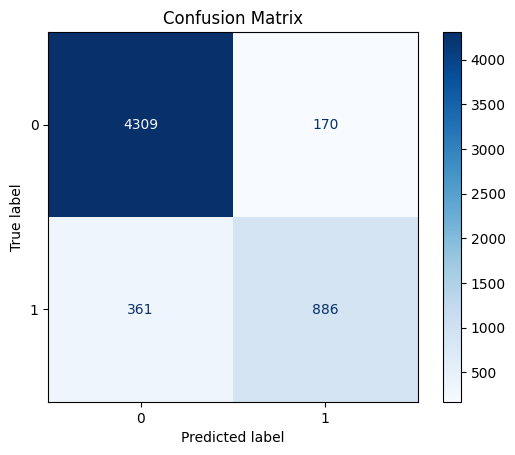

In [5]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
disp.plot(cmap="Blues", values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

c:\Users\damar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


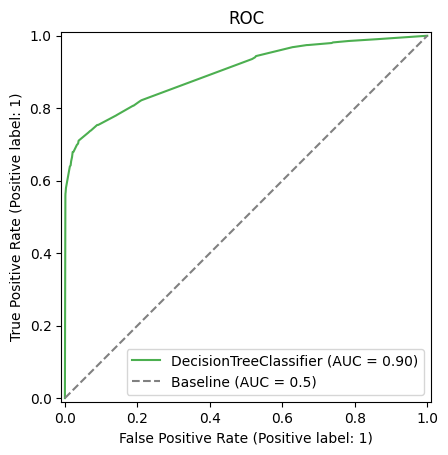

In [6]:
RocCurveDisplay.from_estimator(model, X_test, y_test, color="#4CAF50")
plt.title("ROC")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Baseline (AUC = 0.5)')
plt.legend()
plt.show()

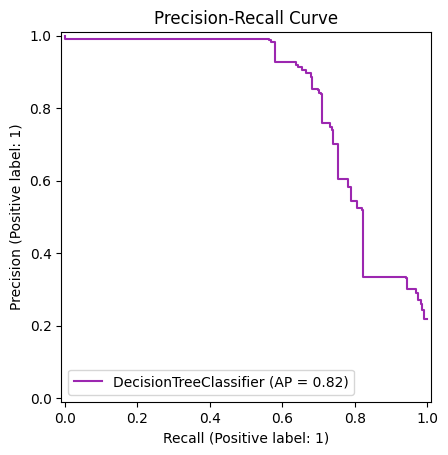

In [7]:
PrecisionRecallDisplay.from_estimator(model, X_test, y_test, color="#9C27B0")
plt.title("Precision-Recall Curve")
plt.show()

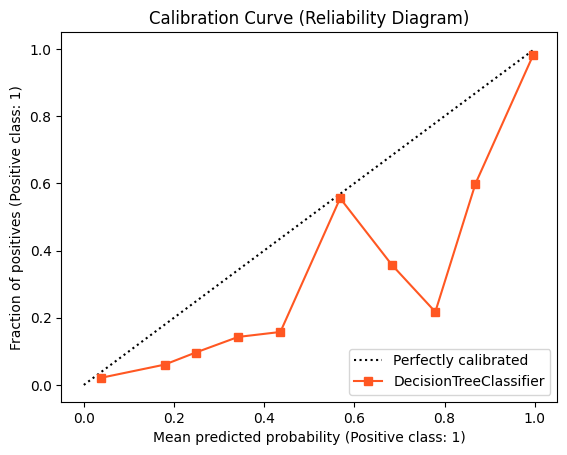

In [8]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(model, X_test, y_test, n_bins=10, color='#FF5722')
plt.title("Calibration Curve (Reliability Diagram)")
plt.show()

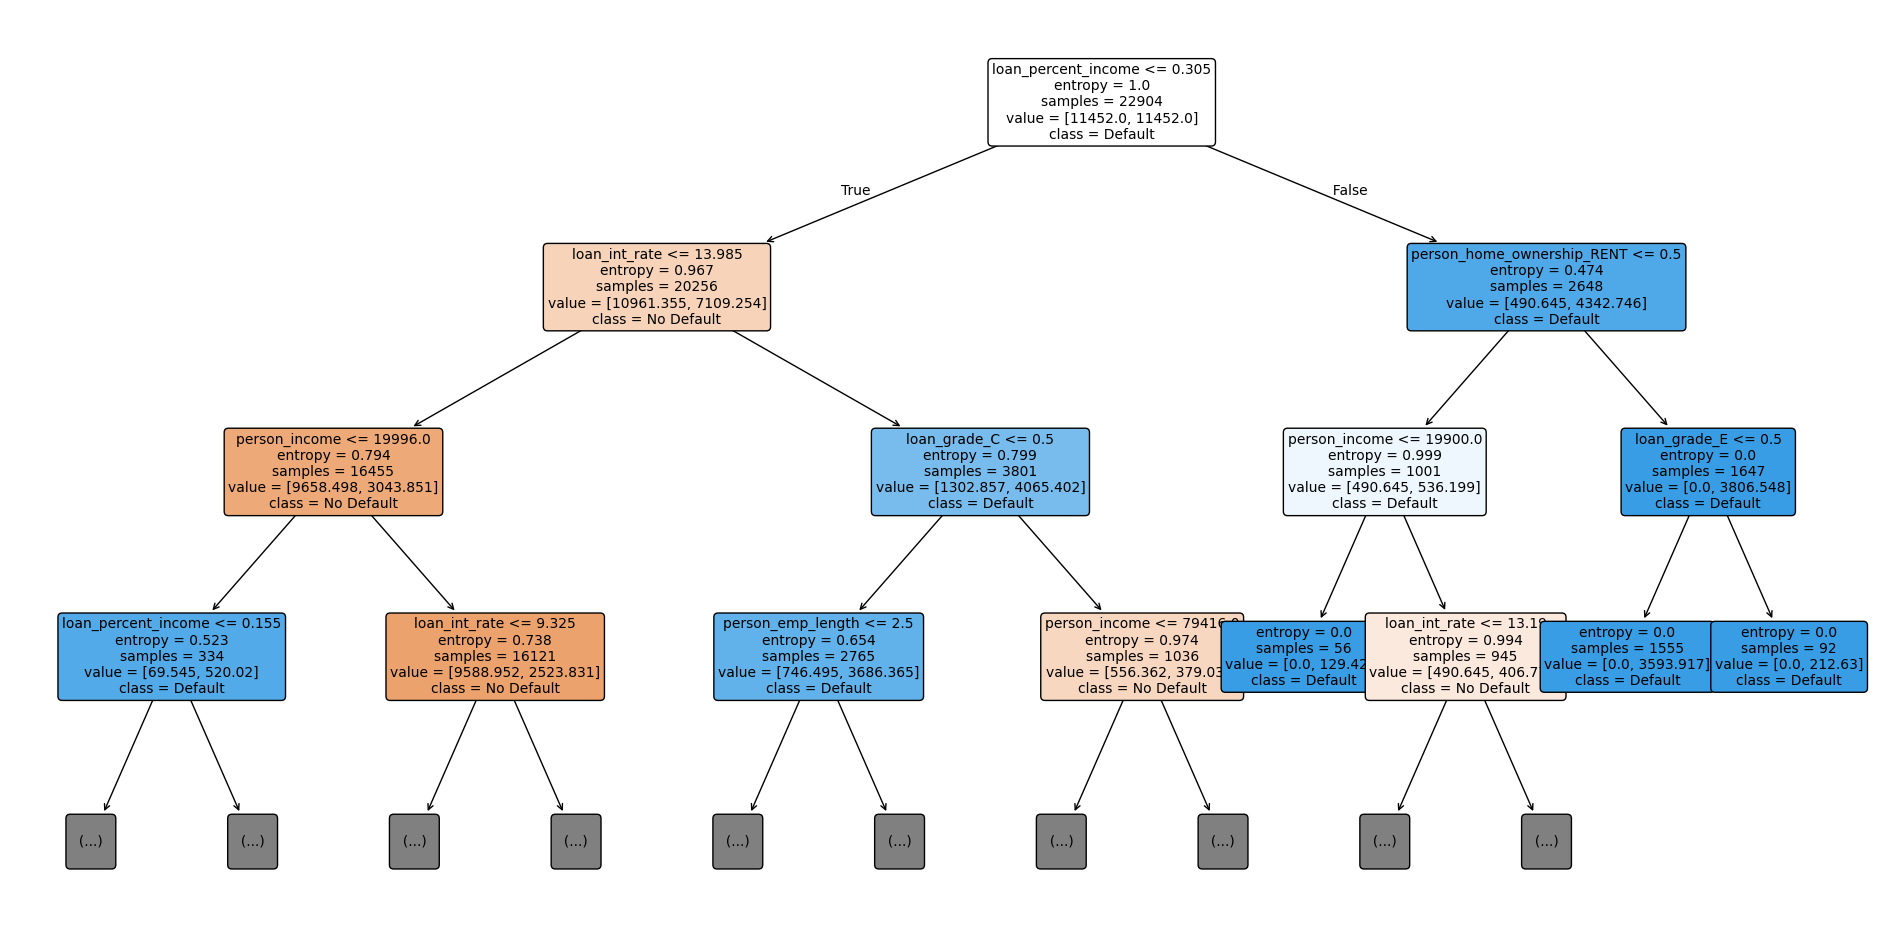

In [9]:
plt.figure(figsize=(24, 12))
plot_tree(model, 
          feature_names=X.columns, 
          class_names=["No Default", "Default"], 
          filled=True, 
          rounded=True, 
          max_depth=3,
          fontsize=10)
plt.show()

In [10]:
os.makedirs("model_save", exist_ok=True)
model_path = "model_save/decision_tree_entropy.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model successfully saved to {model_path}")

Model successfully saved to model_save/decision_tree_entropy.pkl
